In [2]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Processed Dataset(from Q1)

In [3]:
# Load the dataset
df = pd.read_csv('TaxiData.csv')

# Convert trip_start_timestamp to datetime
df['trip_start_timestamp'] = pd.to_datetime(df['trip_start_timestamp'], unit='s')

# Ensure community areas are categorical
df['pickup_community_area'] = df['pickup_community_area'].astype('category')
df['dropoff_community_area'] = df['dropoff_community_area'].astype('category')

import warnings
warnings.filterwarnings("ignore")
# Impute numerical columns with mean
numerical_cols = ['fare', 'trip_miles', 'trip_seconds', 'tips']
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Impute categorical columns with mode or label as 'Unknown'
categorical_cols = ['payment_type', 'company']
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

# Drop rows with missing latitude/longitude data if they are critical
df.dropna(subset=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'], inplace=True)

##  4.a Outliers in Fare and Tips

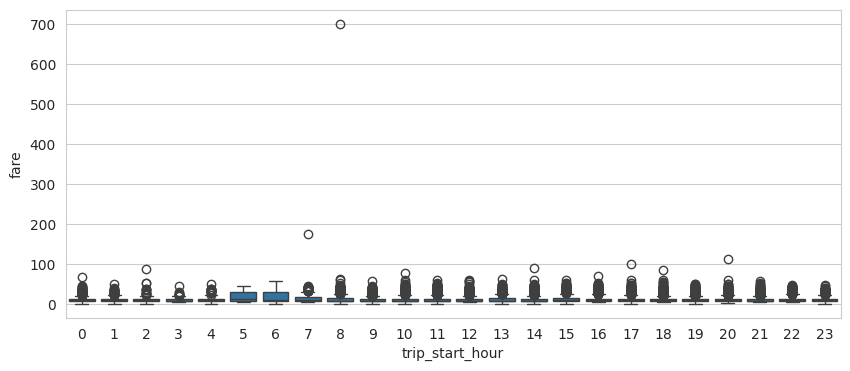

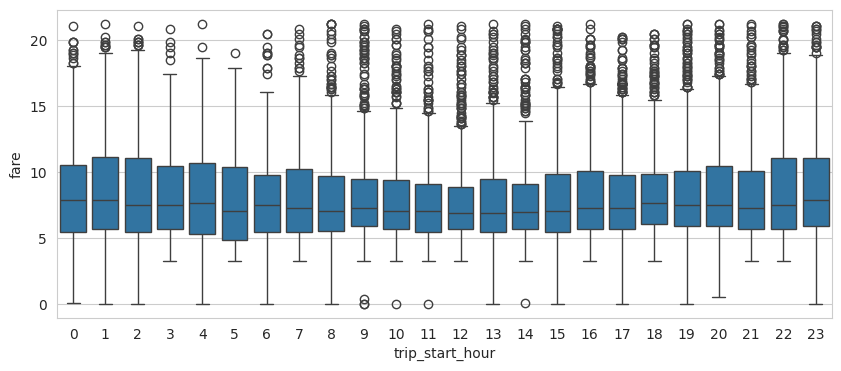

In [6]:

# Extract time-related features if not already in the dataset
df['trip_start_hour'] = df['trip_start_timestamp'].dt.hour
df['trip_start_day'] = df['trip_start_timestamp'].dt.day_name()
df['trip_start_month'] = df['trip_start_timestamp'].dt.month_name()

# Set plot style for better aesthetics
sns.set_style("whitegrid")

# Calculate average fare for each hour
avg_fare_per_hour = df.groupby('trip_start_hour')['fare'].mean().reset_index()

# bar chart for fares vs trip_start_hour
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='trip_start_hour', y='fare')




# Remove outliers based on fare
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1
df_no_outliers = df[~((df['fare'] < (Q1 - 1.5 * IQR)) | (df['fare'] > (Q3 + 1.5 * IQR)))]

# Plot the boxplot again without outliers
plt.figure(figsize=(10,4))
sns.boxplot(data=df_no_outliers, x='trip_start_hour', y='fare')
plt.show()


```
(b) Interpretation: Discuss how these outliers might skew average calculations.
 (c) Suggest methods for handling these outliers in predictive models (e.g., removal
 or adjustment).
```

## 4.b Predicting Fare

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Calculate distance using Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of the Earth in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

# Apply the haversine function to calculate distance
df['calculated_distance'] = df.apply(lambda row: haversine(row['pickup_latitude'], row['pickup_longitude'], row['dropoff_latitude'], row['dropoff_longitude']), axis=1)

# Calculate trip duration in minutes
df['trip_duration_minutes'] = df['trip_seconds'] / 60

# Use these as predictors and apply a regression model to estimate fares

# Define predictors and target variable
X = df[['calculated_distance', 'trip_duration_minutes', 'trip_miles', 'tips']]
y = df['fare']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict fares on the test set
y_pred = model.predict(X_test)

# Calculate and print the root mean squared error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')


Root Mean Squared Error: 20.64747367290242


Here are some potential limitations or areas for improvement in the current model:

1. **Feature Selection**:
    - The model currently uses only a few features (`calculated_distance`, `trip_duration_minutes`, `trip_miles`, `tips`). There might be other relevant features in the dataset that could improve the model's performance, such as `pickup_community_area`, `dropoff_community_area`, `trip_start_hour`, `trip_start_day`, etc.

2. **Handling Categorical Variables**:
    - Categorical variables like `payment_type` and `company` are not included in the model. Encoding these categorical variables and including them as features might improve the model's predictive power.

3. **Outliers**:
    - Although outliers in `fare` were removed, other features might still contain outliers that could affect the model's performance. A more comprehensive outlier detection and removal process could be beneficial.

4. **Model Complexity**:
    - The current model is a simple linear regression. More complex models like Random Forest, Gradient Boosting, or Neural Networks might capture the relationships in the data better.

5. **Feature Engineering**:
    - Additional feature engineering could be performed. For example, creating interaction terms between features or extracting more granular time-based features (e.g., weekend vs. weekday, rush hour vs. non-rush hour).

6. **Evaluation Metrics**:
    - The model is evaluated using RMSE. Other evaluation metrics like Mean Absolute Error (MAE) or R-squared could provide additional insights into the model's performance.

7. **Cross-Validation**:
    - The model's performance is evaluated on a single train-test split. Using cross-validation would provide a more robust estimate of the model's performance.

8. **Data Imputation**:
    - The current imputation strategy for missing values is simple (mean for numerical, mode for categorical). More sophisticated imputation methods could be explored.

9. **Scaling Features**:
    - Features are not scaled. Scaling features might improve the performance of some machine learning algorithms.

10. **Temporal Dependencies**:
     - The model does not account for potential temporal dependencies in the data. Time series analysis techniques could be explored if temporal dependencies are significant.

By addressing these limitations, the model's performance and robustness could be improved.
